In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# <h1 style='text-align:center;'> Netflix </h1>

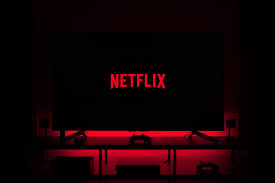

In [ ]:
df = pd.read_csv("../input/netflix-shows/netflix_titles.csv")
df.head()

In [ ]:
df.isna().sum()

**Drop the nan values for visualization process **

In [ ]:
df = df.dropna()
print("The number of rows is {} and column is {}".format(df.shape[1], df.shape[0]))

In [ ]:
df.isna().sum() #Hurray  No null Values 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator


In [ ]:
text = " ".join(review for review in df.listed_in.astype(str))
print ("There are {} words in the combination of all cells in column title.".format(len(text)))


# Generate a word cloud image

wordcloud = WordCloud(background_color="black", width=800, height=400).generate(text)

# Display the generated image:
# the matplotlib way:

plt.axis("off")
plt.figure( figsize=(40,20))
plt.tight_layout(pad=0)
plt.imshow(wordcloud, interpolation='bilinear')
plt.show()

# Visualization

**Types**

In [ ]:
sns.countplot(df['type'])

In [ ]:
labels = ["Movie", "Tv shows"]
plt.pie(df['type'].value_counts(), labels = labels)
plt.show()

In [ ]:
# Which director has make most movies and shows
df['director'].value_counts()

In [ ]:
df1 = df[df['director']=='Raúl Campos, Jan Suter']
df1.head(1)

In [ ]:
df1.type.value_counts()

# Cast

**Which cast has work more**

In [ ]:
df2 = df.cast.value_counts().head(1)
df2.index.to_list()

In [ ]:
print("The cast has work more shows/movies are {}".format(df2.index.to_list()[0]))

**Top 5 countries which produce most movies/series**

In [ ]:
df3 =df['country'].value_counts().head(5)
df3

In [ ]:
sns.barplot(x=df3.index, y=df3.to_list())

# **Release Year**

**Top 10 years in which more movies release**

In [ ]:
df4 = df.release_year.value_counts().head(10)
df4

In [ ]:
sns.barplot(x=df4.index, y=df4.to_list())

In [ ]:
plt.figure(figsize = (12,4))
rate_count = df['release_year'].value_counts()
plt.title("RELEASE RATEs")
sns.lineplot(x =rate_count.index , y= rate_count.values)

# Rating

In [ ]:
sns.countplot(df.rating)

In [ ]:
df["rating"].unique()


# Duration

In [ ]:
df6 = df[df['duration'].str.split(' ').str.get(1)=='min']
df6.head(1)

In [ ]:
df6['duration'] = df6.duration.str.split(' ').str.get(0)
df6.head(1)

In [ ]:
df7 = df6.duration.value_counts().sort_values(ascending=False).head(10)
df7

In [ ]:
sns.barplot(x=df7.index, y=df7.to_list())

# I'm really really Bad in Eda so Please Give me some tips?